<a href="https://colab.research.google.com/github/RhadisyaMeila/ML_recommendation-tanaman-pertanian_RandomForest/blob/main/ML_reco_tanaman_pertanian_RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


/tmp/ipykernel_1449/4243082423.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['label'], palette='Set2')


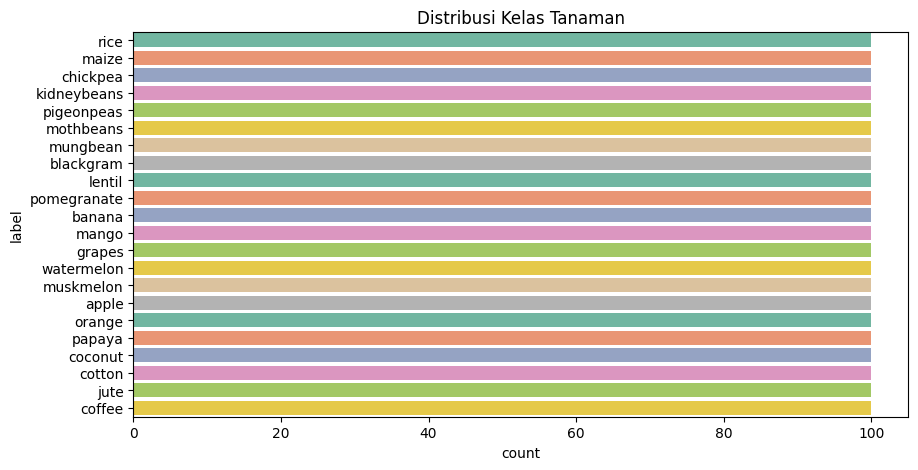

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

# Memuat dataset
df = pd.read_csv('Crop_recommendation.csv')

# Melihat sekilas isi data
display(df.head())
df.info()

# Visualisasi Distribusi Kelas
plt.figure(figsize=(10,5))
sns.countplot(y=df['label'], palette='Set2')
plt.title("Distribusi Kelas Tanaman")
plt.show()

In [ ]:
# Memisahkan Fitur (X) dan Target (y)
X = df.drop('label', axis=1)
y = df['label']

# Mengubah nama tanaman (teks) menjadi angka
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Membagi data latih (80%) dan data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Standarisasi skala fitur numerik
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preparation Selesai!")

Data Preparation Selesai!


In [ ]:
# Inisialisasi model Random Forest
model_utama = RandomForestClassifier(n_estimators=100, random_state=42)

# Melatih model
model_utama.fit(X_train_scaled, y_train)

# Melakukan prediksi pada data uji
y_pred = model_utama.predict(X_test_scaled)

print("Model berhasil dilatih!")

Model berhasil dilatih!


Akurasi Model Random Forest: 99.32%

Laporan Klasifikasi:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.0

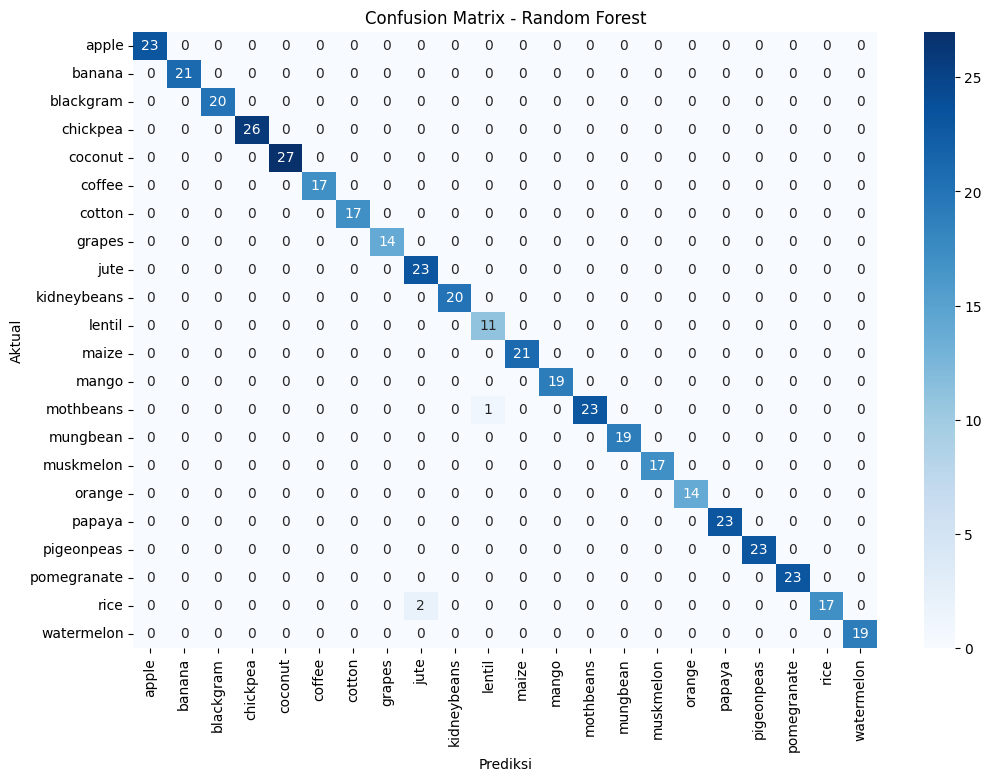

In [ ]:
# Mengukur akurasi
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi Model Random Forest: {akurasi * 100:.2f}%\n")

# Menampilkan laporan detail
print("Laporan Klasifikasi:\n", classification_report(y_test, y_pred, target_names=le.classes_))

# Visualisasi Confusion Matrix
plt.figure(figsize=(12,8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Random Forest")
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

In [ ]:
# Menyimpan model, scaler, dan encoder
with open('crop_model.pkl', 'wb') as f:
    pickle.dump(model_utama, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Model dan alat preprocessing berhasil disimpan untuk deployment!")

Model dan alat preprocessing berhasil disimpan untuk deployment!


In [ ]:
%%writefile streamlit_app.py
import streamlit as st
import pandas as pd
import pickle
import numpy as np

# Load model dan alat preprocessing
model = pickle.load(open('crop_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))
le = pickle.load(open('label_encoder.pkl', 'rb'))

st.set_page_config(page_title="Rekomendasi Tanaman", page_icon="🌱")

st.title("🌱 Sistem Rekomendasi Tanaman Pertanian Pintar")
st.write("Aplikasi ini memprediksi tanaman apa yang paling cocok ditanam berdasarkan data sensor lingkungan dan tanah. Dibuat menggunakan algoritma **Random Forest**.")

st.sidebar.header("Masukkan Parameter Lingkungan")
N = st.sidebar.slider("Nitrogen (N)", 0, 140, 50)
P = st.sidebar.slider("Fosfor (P)", 5, 145, 50)
K = st.sidebar.slider("Kalium (K)", 5, 205, 50)
temp = st.sidebar.slider("Suhu Lingkungan (°C)", 5.0, 45.0, 25.0)
humidity = st.sidebar.slider("Kelembapan (%)", 10.0, 100.0, 70.0)
ph = st.sidebar.slider("pH Tanah", 3.0, 9.0, 6.5)
rainfall = st.sidebar.slider("Curah Hujan (mm)", 20.0, 300.0, 100.0)

st.write("### Data yang Anda masukkan:")
input_df = pd.DataFrame([[N, P, K, temp, humidity, ph, rainfall]],
                        columns=['Nitrogen', 'Fosfor', 'Kalium', 'Suhu', 'Kelembapan', 'pH', 'Curah Hujan'])
st.dataframe(input_df)

if st.button("Rekomendasikan Tanaman 🚀"):
    user_data = np.array([[N, P, K, temp, humidity, ph, rainfall]])
    user_data_scaled = scaler.transform(user_data)
    prediction_encoded = model.predict(user_data_scaled)
    prediction_tanaman = le.inverse_transform(prediction_encoded)

    st.success(f"🌾 Berdasarkan kondisi lingkungan, tanaman yang direkomendasikan adalah: **{prediction_tanaman[0].upper()}**")

Writing streamlit_app.py


In [ ]:
%%writefile requirements.txt
pandas
scikit-learn
streamlit
matplotlib
seaborn

Writing requirements.txt
